# VIC DET - School Zones - Secondary Year 9 (Polygon) 2020
Based on paper:   
<div align="center">
<b>Procedural modeling applied to the 3D city model of Bogota: A case study</b>
</div>


| No.     | Title                                               | Purpose                                                                                   |
| ------- | --------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| **0**   | Environment Setup                                   | Install dependencies like `geopandas`, `shapely`, `networkx`, etc. (run once only)        |
| **1**   | Load Dataset                                        | Load the XML/GML file into a `GeoDataFrame` and preview basic metadata                    |
| **2**   | Geometry Validity Check                             | Use `is_valid` and `is_simple` to detect topology errors, self-intersections, etc.        |
| **3**   | Overlap & Topology Conflict Detection               | Detect overlapping polygons via pairwise intersection area                                |
| **4**   | Boundary Adjacency Graph (NetworkX)                 | Construct a polygon `touches()` graph and analyze connected components                    |
| **5**   | Triangulation Closure Check (2D watertight analogy) | Check if polygons are hole-free via triangulation and area conservation                   |
| **6**   | Export Reports (Basic Validation)                   | Save reports for basic checks to CSV files                                                |
| **7**   | Extended Validation                                 | Save reports for basic checks to CSV files                                                |
| **7-1** | Minimum Area & Sliver Detection                     | Identify polygons with extremely small area or elongated shape (high sliver ratio)        |
| **7-2** | Minimum Edge Length Check                           | Detect polygons containing abnormally short edges                                         |
| **7-3** | Ring Orientation Check                              | Determine if polygon exterior rings are wrongly oriented (e.g., clockwise instead of CCW) |
| **7-4** | Duplicate Geometry Check                            | Detect completely identical polygons (based on WKT string comparison)                     |
| **7-5** | Non-manifold Edge Check (2D Analog)                 | Identify edges shared by more than two polygons (indicative of non-manifoldness)          |
| **7-6** | Acute Angle Check (< ε)                             | Detect vertex angles below a certain threshold (e.g., < 5°)                               |
| **7-7** | Coordinate Precision Check                          | Detect polygons with excessive decimal digits in coordinates                              |
| **7-8** | Out-of-Bounds Check                                 | Determine whether polygons fall outside a predefined bounding box                         |
| **7-9**   | Export Reports (Extended Validation)              | Export all extra validation results (from Sections 8-1 to 8-8) into a single CSV          |
| **8**   | Validation Method – Paper Mapping Table             | Map each validation method to corresponding section in the paper                          |


## 0. Environment Setup

In [1]:
import geopandas as gpd
from shapely import validation
import pandas as pd
from itertools import combinations
import networkx as nx
from shapely.ops import triangulate
import matplotlib.pyplot as plt


## 1. Load Dataset

In [2]:
file_path = r"C:\Users\86125\Downloads\vic-govt-det-vic-det-school-zone-secondary-year9-2020-na.xml"
gdf = gpd.read_file(file_path)
gdf = gdf.reset_index(drop=True)   
print(f"Reads a total of {len(gdf)} school partitions")
gdf.head()


Reads a total of 301 school partitions


,gml_id,ogc_fid,school_name,campus_name,entity_code,year_level,boundary_year,geometry
0,vic_det_school_zone_secondary_year9_2020.1,1,Koo Wee Rup Secondary College,Koo Wee Rup Secondary College,1795501,9,2020,"MULTIPOLYGON (((145.44638 -38.1375, 145.6594 -..."
1,vic_det_school_zone_secondary_year9_2020.2,2,Pakenham Secondary College,Pakenham Secondary College,1822301,9,2020,"MULTIPOLYGON (((145.6594 -38.11167, 145.44638 ..."
2,vic_det_school_zone_secondary_year9_2020.3,3,Phoenix P-12 Community College,Sebastopol Campus,1890001,9,2020,"MULTIPOLYGON (((143.53234 -37.65873, 143.85475..."
3,vic_det_school_zone_secondary_year9_2020.4,4,Ballarat High School,Ballarat High School,1754001,9,2020,"MULTIPOLYGON (((143.85475 -37.56184, 143.53234..."
4,vic_det_school_zone_secondary_year9_2020.5,5,Woodmans Hill Secondary College,Woodmans Hill Campus,1849101,9,2020,"MULTIPOLYGON (((143.85634 -37.54563, 143.98962..."


## 2. Geometry Validity Check（Validity & Simplicity）

In [3]:
gdf["is_valid"] = gdf.is_valid
gdf["validity_reason"] = gdf.geometry.apply(
    lambda geom: "Valid" if geom.is_valid else validation.explain_validity(geom)
)

gdf["is_simple"] = gdf.geometry.apply(lambda geom: geom.is_simple)

print("Number of invalid polygons:", (~gdf.is_valid).sum())
print("Number of non-simple polygons:", (~gdf.is_simple).sum())


Number of invalid polygons: 0
Number of non-simple polygons: 0


## 3. Overlap & Topology Conflict Detection

In [4]:
overlaps = []
for i, j in combinations(gdf.index, 2):
    gi, gj = gdf.geometry[i], gdf.geometry[j]
    if gi.intersects(gj):            
        inter = gi.intersection(gj)
        if not inter.is_empty and inter.area > 0:   
            overlaps.append({"idx1": i,
                             "idx2": j,
                             "school1": gdf.at[i, "school_name"],
                             "school2": gdf.at[j, "school_name"],
                             "overlap_area": inter.area})
overlap_df = pd.DataFrame(overlaps)
print("Overlapping logarithms:", len(overlap_df))
overlap_df.head()


Overlapping logarithms: 0


""


## 4. Boundary Adjacency Graph (NetworkX)

In [5]:
G = nx.Graph()

for idx, row in gdf.iterrows():
    G.add_node(idx, school=row["school_name"])

for i, j in combinations(gdf.index, 2):
    if gdf.geometry[i].touches(gdf.geometry[j]):
        G.add_edge(i, j)

try:
    print(nx.info(G))                              # NetworkX 2.x
except AttributeError:                            # NetworkX 3.x
    print(
        f"Graph with {G.number_of_nodes()} nodes "
        f"and {G.number_of_edges()} edges\n"
        f"Average degree: {sum(dict(G.degree()).values())/G.number_of_nodes():.2f}"
    )

components = list(nx.connected_components(G))
print("Number of connected components:", len(components))


Graph with 301 nodes and 808 edges
Average degree: 5.37
Number of connected components: 3


Visualize the maximum connectivity block:

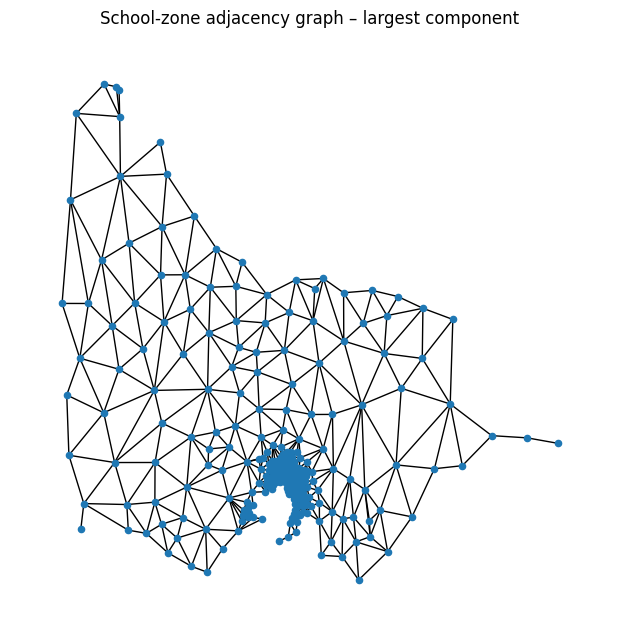

In [6]:
largest = max(components, key=len)
pos = {idx: (gdf.geometry[idx].centroid.x, gdf.geometry[idx].centroid.y) for idx in largest}

plt.figure(figsize=(6, 6))
nx.draw(G.subgraph(largest), pos, node_size=20, with_labels=False)
plt.title("School-zone adjacency graph – largest component")
plt.show()


## 5. Triangulation Closure Check (2D watertight analogy)

In [7]:
def triangulation_closed(geom, tol=1e-1):
    tris = triangulate(geom)
    tri_area = sum(t.area for t in tris)
    return abs(tri_area - geom.area) < tol

gdf["triang_closed"] = gdf.geometry.apply(triangulation_closed)
print("Inconsistency in the area of the triangular section (potential gaps):", (~gdf.triang_closed).sum())


Inconsistency in the area of the triangular section (potential gaps): 3


Show previous data

In [8]:
invalid_triang = gdf[~gdf.triang_closed]
invalid_triang = invalid_triang.reset_index()
invalid_triang[["index", "school_name", "geometry"]].head()

,index,school_name,geometry
0,66,Orbost Secondary College,"MULTIPOLYGON (((148.4567 -36.90339, 148.50124 ..."
1,269,Swifts Creek P-12 School,"MULTIPOLYGON (((148.1216 -36.76468, 148.12121 ..."
2,270,Foster Secondary College,"MULTIPOLYGON (((146.49273 -38.69585, 146.49184..."


In [9]:
# gdf.loc[~gdf.triang_closed, ["school_name", "triang_closed"]].to_csv("triangulation_inconsistency_report.csv", index=False)

Sort to see the ones with the largest errors

In [10]:
from shapely.ops import triangulate

def triang_area_diff(geom):
    tris = triangulate(geom)
    tri_area = sum(t.area for t in tris)
    return abs(tri_area - geom.area)

gdf["triang_error"] = gdf.geometry.apply(triang_area_diff)

gdf[~gdf.triang_closed].sort_values("triang_error", ascending=False)[["school_name", "triang_error"]].head()


,school_name,triang_error
269,Swifts Creek P-12 School,0.128006
270,Foster Secondary College,0.115389
66,Orbost Secondary College,0.110192


Visualize a few randomly selected non-closed faces

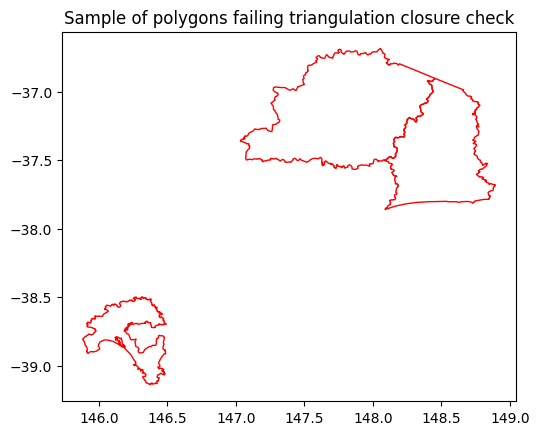

In [11]:
import matplotlib.pyplot as plt

invalid_sample = invalid_triang.sample(3, random_state=42)
invalid_sample.plot(edgecolor='red', facecolor='none')
plt.title("Sample of polygons failing triangulation closure check")
plt.show()


## 6. Export Reports (Basic Validation)

In [12]:
issues_basic = gdf[~gdf.is_valid | ~gdf.is_simple]
issues_basic[["school_name", "is_valid", "is_simple", "validity_reason"]]\
    .to_csv("VIC9SD_invalid_polygons.csv", index=False)

overlap_df.to_csv("VIC9SD_polygon_overlaps.csv", index=False)

gdf[~gdf.triang_closed][["school_name"]].to_csv("VIC9SD_triangulation_gaps.csv", index=False)

print("✓ CSV Report generated：invalid_polygons.csv, polygon_overlaps.csv, triangulation_gaps.csv")


✓ CSV Report generated：invalid_polygons.csv, polygon_overlaps.csv, triangulation_gaps.csv


## 7. Extended validation

### 7.1 Minimum Area & Sliver Detection

In [13]:
MIN_AREA = 10.0       
SLIVER_RATIO = 15            

gdf["too_small_area"] = gdf.geometry.area < MIN_AREA
gdf["is_sliver"] = (gdf.geometry.length ** 2) / (4 * 3.1416 * gdf.geometry.area) > SLIVER_RATIO
print("too small areas:", gdf.too_small_area.sum(), "| Sliver:", gdf.is_sliver.sum())


too small areas: 301 | Sliver: 0


### 7.2 Minimum Edge Length Check

In [14]:
from shapely.geometry import Polygon, MultiPolygon, LineString

def has_short_edges(geom, min_len=2.0):
    def edge_too_short(coords):
        return any(LineString([coords[i], coords[i+1]]).length < min_len
                   for i in range(len(coords)-1))

    if isinstance(geom, Polygon):
        return edge_too_short(list(geom.exterior.coords))
    
    elif isinstance(geom, MultiPolygon):
        for poly in geom.geoms:
            if edge_too_short(list(poly.exterior.coords)):
                return True
        return False
    
    else:
        return False  

gdf["short_edge"] = gdf.geometry.apply(has_short_edges)
print("Polygons with too short sides: ", gdf.short_edge.sum())


Polygons with too short sides:  301


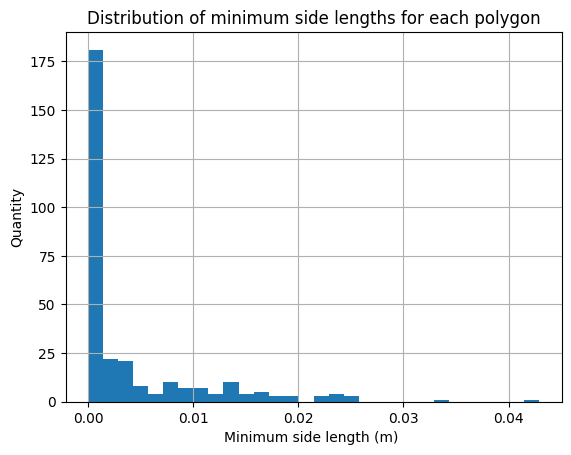

In [15]:
def min_edge_length(geom):
    def edge_lengths(coords):
        return [LineString([coords[i], coords[i+1]]).length
                for i in range(len(coords)-1)]

    if isinstance(geom, Polygon):
        return min(edge_lengths(list(geom.exterior.coords)))
    
    elif isinstance(geom, MultiPolygon):
        min_lengths = []
        for poly in geom.geoms:
            min_lengths += edge_lengths(list(poly.exterior.coords))
        return min(min_lengths) if min_lengths else None
    else:
        return None

gdf["min_edge_len"] = gdf.geometry.apply(min_edge_length)

gdf["min_edge_len"].hist(bins=30)
plt.xlabel("Minimum side length (m) ")
plt.ylabel("Quantity")
plt.title("Distribution of minimum side lengths for each polygon")
plt.show()


### 7.3 Ring Orientation Consistency Check

In [16]:
from shapely.geometry.polygon import orient

def wrong_orientation(poly):
    ext_ccw = orient(poly, sign=1.0)         # 保证外环 CCW
    return not poly.equals_exact(ext_ccw, 1e-8)

gdf["wrong_orientation"] = gdf.geometry.apply(wrong_orientation)
print("Outer ring in the wrong order:", gdf.wrong_orientation.sum())


Outer ring in the wrong order: 301


### 7.4 Duplicate / Overlapping Duplicate Geometry Check

In [17]:
gdf["dup_id"] = None
geom_map = {}

for idx, geom in gdf.geometry.items():
    wkt = geom.wkt
    if wkt in geom_map:
        gdf.at[idx, "dup_id"] = geom_map[wkt]
    else:
        geom_map[wkt] = idx

print("Duplicate geometry detected:", gdf["dup_id"].notna().sum())


Duplicate geometry detected: 0


### 7.5 Non-manifold Edge Check (2D Analog)

In [18]:
from collections import Counter
from shapely.geometry import Polygon, MultiPolygon

edge_ct = Counter()

def extract_edges(geom):
    edges = []
    if isinstance(geom, Polygon):
        rings = [geom.exterior]
    elif isinstance(geom, MultiPolygon):
        rings = [p.exterior for p in geom.geoms]
    else:
        return []

    for ring in rings:
        coords = list(ring.coords)
        for i in range(len(coords) - 1):
            a, b = coords[i], coords[i+1]
            edge = tuple(sorted([a, b]))
            edges.append(edge)
    return edges

for poly in gdf.geometry:
    for edge in extract_edges(poly):
        edge_ct[edge] += 1

nonmanifold_edges = [e for e, c in edge_ct.items() if c > 2]

def has_nonmanifold(geom):
    for edge in extract_edges(geom):
        if edge in nonmanifold_edges:
            return True
    return False

gdf["nonmanifold_edge"] = gdf.geometry.apply(has_nonmanifold)
print("Number of polygons with non-flowing edges：", gdf["nonmanifold_edge"].sum())


Number of polygons with non-flowing edges： 0


### 7.6 Acute Angle  Angle (< ε)

In [19]:
import math
from shapely.geometry import Polygon, MultiPolygon

MIN_ANGLE = 5        

def compute_min_angle(polygon):
    coords = list(polygon.exterior.coords)[:-1]
    min_ang = 180
    for i in range(len(coords)):
        p_prev = coords[i - 1]
        p = coords[i]
        p_next = coords[(i + 1) % len(coords)]
        v1 = (p_prev[0] - p[0], p_prev[1] - p[1])
        v2 = (p_next[0] - p[0], p_next[1] - p[1])
        try:
            ang = math.degrees(
                math.acos(
                    (v1[0]*v2[0] + v1[1]*v2[1]) /
                    (math.hypot(*v1) * math.hypot(*v2) + 1e-9)
                )
            )
            min_ang = min(min_ang, ang)
        except:
            continue
    return min_ang

def min_angle_dispatch(geom):
    if geom.is_empty:
        return None
    elif isinstance(geom, Polygon):
        return compute_min_angle(geom)
    elif isinstance(geom, MultiPolygon):
        angles = [compute_min_angle(p) for p in geom.geoms if isinstance(p, Polygon)]
        return min(angles) if angles else None
    else:
        return None

gdf["min_angle"] = gdf.geometry.apply(min_angle_dispatch)
gdf["acute_angle"] = gdf["min_angle"] < MIN_ANGLE
print("Polygons with <5° sharp corners:", gdf.acute_angle.sum())


Polygons with <5° sharp corners: 4


### 7.7 Coordinate Precision Check

In [20]:
MAX_DECIMALS = 3  # Up to three decimal places permitted (in millimeters)

def excessive_precision(geom):
    polygons = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
    
    for poly in polygons:
        for x, y in poly.exterior.coords:
            x_decimals = len(str(x).split('.')[-1]) if '.' in str(x) else 0
            y_decimals = len(str(y).split('.')[-1]) if '.' in str(y) else 0
            if x_decimals > MAX_DECIMALS or y_decimals > MAX_DECIMALS:
                return True
    return False

gdf["excessive_precision"] = gdf.geometry.apply(excessive_precision)
print("Number of faces with too many decimal places in coordinates:", gdf.excessive_precision.sum())


Number of faces with too many decimal places in coordinates: 301


### 7.8 Out-of-Bounds Check

In [21]:
from shapely.geometry import box  

BBOX = ((140, -40), (150, -33))  # (minx, miny), (maxx, maxy)

def outside_bbox(poly, bbox=BBOX):
    (minx, miny), (maxx, maxy) = bbox
    return not poly.within(box(minx, miny, maxx, maxy))

gdf["outside_bbox"] = gdf.geometry.apply(outside_bbox)
print("Exceeding the expected scope of the data set:", gdf.outside_bbox.sum())


Exceeding the expected scope of the data set: 0


### 7.9 Export Reports (Extended Validation)

In [22]:
extra_cols = [
    "too_small_area", "is_sliver", "short_edge", "wrong_orientation",
    "dup_id", "nonmanifold_edge", "acute_angle",
    "excessive_precision", "outside_bbox"
]

gdf[["school_name", *extra_cols]]\
    .query(" or ".join(extra_cols))\
    .to_csv("VIC9SD_extra_validation_issues.csv", index=False)

print("✓ Extended validation reports have been generated:VIC9SD_extra_validation_issues.csv")


✓ Extended validation reports have been generated:VIC9SD_extra_validation_issues.csv


## 8 Validation Method – Paper Mapping Table

| Paper Section | Validation Dimension                    | Variable or Method Used       | Code Section |
| ------------- | --------------------------------------- | ----------------------------- | ------------ |
| 3.1.1         | Valid polygon closure and structure     | `is_valid`, `validity_reason` | Section 2    |
| 3.1.2         | Minimum coordinate precision            | `excessive_precision`         | Section 8-7  |
| 3.1.3         | Polygon closure via triangulation       | `triang_closed`               | Section 5    |
| 3.1.4         | Duplicate surface geometry              | `dup_id`                      | Section 8-4  |
| 3.1.5         | Ring orientation consistency            | `wrong_orientation`           | Section 8-3  |
| 3.1.6         | Minimum area threshold                  | `too_small_area`              | Section 8-1  |
| 3.1.7         | Sliver geometry detection               | `is_sliver`                   | Section 8-1  |
| 3.1.8         | Minimum edge length                     | `short_edge`                  | Section 8-2  |
| 3.1.9         | Minimum interior angle                  | `min_angle`, `acute_angle`    | Section 8-6  |
| 3.2.1         | Non-manifold edges (shared >2)          | `nonmanifold_edge`            | Section 8-5  |
| 3.2.2         | Overlapping faces                       | `overlap_df`                  | Section 3    |
| 3.2.3         | Self-intersections / topological errors | `is_simple`                   | Section 2    |
| 3.2.4         | Out-of-bounds geometries                | `outside_bbox`                | Section 8-8  |
| 3.2.5         | Region adjacency graph                  | `NetworkX` graph `G`          | Section 4    |
